<a href="https://colab.research.google.com/github/prembaraili12-crypto/Thesis/blob/main/Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 0) SETUP (Colab + GPU)
# ==========================================

!pip -q install imbalanced-learn

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Make GPU memory allocation smoother
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

!nvidia-smi

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Tue Mar 24 11:41:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |     

This code installs the necessary libraries and imports tools to be used in data analysis, visualizations, machine learning, or deep learning. It checks the TensorFlow version and checks whether a GPU is available or not, finally setting up the GPU to save memory better, such that it allocates memory right before using an array instead of everything at a go. It then runs `nvidia-smi` to display GPU details in order confirm that the system is ready for accelerated computation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This code imports Google Colab's drive module and mounts your Google Drive into the Colab environment. This is to make a chance to access files from your Drive (such as datasets or notebooks) by using the path `/content/drive`.

In [ ]:
# ==========================================
# 1) LOAD DATA
# ==========================================

# Option A: If uploaded to Colab "Files"
CSV_PATH = "/content/onlinefraud.csv"


df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
display(df.head())

print("\nMissing values:\n", df.isnull().sum())
print("\nFraud distribution:\n", df["isFraud"].value_counts())
print("\nFraud rate (%):", df["isFraud"].mean() * 100)

Shape: (409488, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0



Missing values:
 step              0
type              0
amount            1
nameOrig          1
oldbalanceOrg     1
newbalanceOrig    1
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64

Fraud distribution:
 isFraud
0.0    409278
1.0       209
Name: count, dtype: int64

Fraud rate (%): 0.05103947133852845


This code reads in the dataset from a CSV file into a `pandas` DataFrame and shows the shape and first few rows for a quick overview. It then checks for missing values in each column to get an idea about potential data quality issues. It's intended to look at the target variable (`isFraud`) by displaying the number of fraud cases versus non-fraud cases and calculating the fraud percentage.

In [ ]:
# ==========================================
# 2) PREPROCESSING (clean + encode + scale)
# ==========================================

# Drop high-cardinality IDs
df = df.drop(["nameOrig", "nameDest"], axis=1)

# One-hot encode transaction type
df = pd.get_dummies(df, columns=["type"], drop_first=False)

# Feature Engineering (combined)
df["balanceDiff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["destBalanceDiff"] = df["newbalanceDest"] - df["oldbalanceDest"]
df["largeTransaction"] = (df["amount"] > df["amount"].mean()).astype(int)
df["zeroBalance"] = ((df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0)).astype(int)
df["amountRatio"] = df["amount"] / (df["oldbalanceOrg"] + 1)  # avoid divide-by-zero

# Scale numeric columns (keep indicator/dummy columns unscaled)
numeric_cols = [
    "step", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "balanceDiff", "destBalanceDiff", "amountRatio"
]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Ensure everything is numeric (prevents dtype object errors later)
df = df.apply(pd.to_numeric, errors="coerce").fillna(0)

print("After preprocessing:", df.shape)
print("Any non-numeric dtypes?\n", df.dtypes[df.dtypes == "object"])
display(df.head())

After preprocessing: (409488, 19)
Any non-numeric dtypes?
 Series([], dtype: object)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,balanceDiff,destBalanceDiff,largeTransaction,zeroBalance,amountRatio
0,-3.63014,-0.570159,-0.247415,-0.254157,-0.418346,-0.463398,0.0,0.0,False,False,False,False,True,False,0.232982,-0.289224,0,0,-0.305442
1,-3.63014,-0.598153,-0.297653,-0.301115,-0.418346,-0.463398,0.0,0.0,False,False,False,False,True,False,0.169849,-0.289224,0,0,-0.305442
2,-3.63014,-0.604061,-0.304762,-0.307575,-0.418346,-0.463398,1.0,0.0,False,False,False,False,False,True,0.156525,-0.289224,0,1,-0.305437
3,-3.63014,-0.604061,-0.304762,-0.307575,-0.409342,-0.463398,1.0,0.0,False,False,True,False,False,False,0.156525,-0.320602,0,1,-0.305437
4,-3.63014,-0.563741,-0.290801,-0.297615,-0.418346,-0.463398,0.0,0.0,False,False,False,False,True,False,0.247456,-0.289224,0,0,-0.305441


This code removes unnecessary ID columns and converts its transaction type into a numerical format using one-hot encoding before it uses numerical data to form new useful characteristics (e.g., difference in balance or a pattern of transactions) and scales numeric column data to be later standardized. Finally, it ensures that all data is clean and numeric and shows the updated structure of the dataset.

In [ ]:
# ==========================================
# 3) TRAIN/TEST SPLIT
# ==========================================

X = df.drop("isFraud", axis=1)
y = df["isFraud"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train fraud count:", int(y_train.sum()), "out of", len(y_train))
print("Test fraud count :", int(y_test.sum()), "out of", len(y_test))

Train: (654846, 18) Test: (81898, 18)
Train fraud count: 327423 out of 654846
Test fraud count : 42 out of 81898


The code will feature separation (X) from the target variable (y = isFraud), as well as splitting the data into training and testing subsets in order to preserve the fraud proportion during stratification. The same code then applies **SMOTE** to the training data so as to oversample the minority fraud class and reduce class imbalance. Finally, it prints the dataset sizes and the number of fraud cases in both train and test set so that the split and balancing can be verified.


===== Random Forest =====
              precision    recall  f1-score   support

           0     1.0000    0.9996    0.9998     81856
           1     0.5507    0.9048    0.6847        42

    accuracy                         0.9996     81898
   macro avg     0.7753    0.9522    0.8422     81898
weighted avg     0.9997    0.9996    0.9996     81898



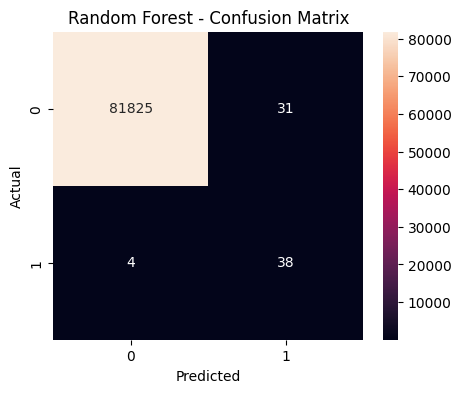

RF ROC-AUC: 0.9631
RF PR-AUC : 0.8447


In [ ]:
# ==========================================
# 4) BASELINE ML MODEL (Random Forest - CPU)
# ==========================================

# For huge datasets, RF can be slow. If needed, you can train on a sample:
# sample_n = 800_000
# idx = np.random.choice(len(X_train), sample_n, replace=False)
# X_train_rf, y_train_rf = X_train.iloc[idx], y_train.iloc[idx]
# Otherwise use full:
X_train_rf, y_train_rf = X_train, y_train

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_rf, y_train_rf)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("\n===== Random Forest =====")
print(classification_report(y_test, rf_pred, digits=4))

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc = roc_auc_score(y_test, rf_proba)
precision, recall, _ = precision_recall_curve(y_test, rf_proba)
pr_auc = auc(recall, precision)
print(f"RF ROC-AUC: {roc:.4f}")
print(f"RF PR-AUC : {pr_auc:.4f}")

The code trains (optionally, a sample may be drawn for speed) a Random Forest classifier on the training data, selects prediction of the test set, checks the performance of classification report and confusion matrix visualization, and computes additional performance metrics like ROC-AUC and PR-AUC for assessing how well the model is able to detect the minority class (fraud).

Class weights: {0: 1.0, 1: 1.0}
Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9015 - loss: 0.2433 - val_accuracy: 0.7653 - val_loss: 0.4289
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9173 - loss: 0.2548 - val_accuracy: 0.7841 - val_loss: 0.3916
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9485 - loss: 0.1381 - val_accuracy: 0.8439 - val_loss: 0.2990
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9708 - loss: 0.0841 - val_accuracy: 0.8902 - val_loss: 0.2410
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9797 - loss: 0.0604 - val_accuracy: 0.9252 - val_loss: 0.1731
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9844 - loss: 0.0472 - val_accuracy: 0.9412 - val_loss: 0.1503
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9870 - loss: 0.0395 - val_accuracy: 0.9437 - val_loss: 0.1474
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy:

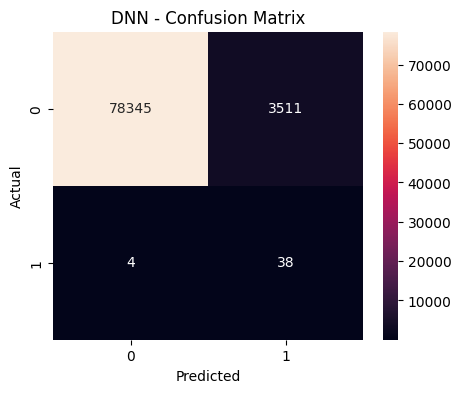

DNN ROC-AUC: 0.9519
DNN PR-AUC : 0.6616


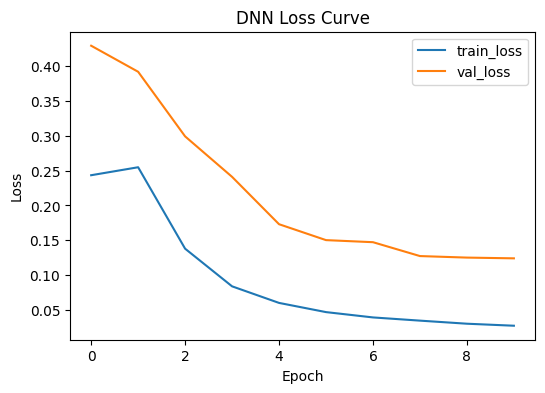

In [ ]:
# ==========================================
# 5) DEEP LEARNING (DNN) - GPU
# Use class weights (faster + avoids SMOTE on huge data)
# ==========================================

# Convert to float32 arrays (GPU-friendly)
X_train_dl = X_train.to_numpy(dtype=np.float32)
X_test_dl  = X_test.to_numpy(dtype=np.float32)
y_train_dl = y_train.to_numpy(dtype=np.int32)
y_test_dl  = y_test.to_numpy(dtype=np.int32)

# Compute class weights
classes = np.unique(y_train_dl)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_dl)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

# tf.data pipeline (faster feeding to GPU)
BATCH_SIZE = 4096  # if OOM: 2048 or 1024
train_ds = tf.data.Dataset.from_tensor_slices((X_train_dl, y_train_dl)) \
    .shuffle(200000) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_dl, y_test_dl)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

tf.random.set_seed(42)

dnn = Sequential([
    Input(shape=(X_train_dl.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

dnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = dnn.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)

dnn_proba = dnn.predict(test_ds).ravel()
dnn_pred = (dnn_proba >= 0.5).astype(int)

print("\n===== Deep Learning (DNN) =====")
print(classification_report(y_test_dl, dnn_pred, digits=4))

cm = confusion_matrix(y_test_dl, dnn_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("DNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc = roc_auc_score(y_test_dl, dnn_proba)
precision, recall, _ = precision_recall_curve(y_test_dl, dnn_proba)
pr_auc = auc(recall, precision)
print(f"DNN ROC-AUC: {roc:.4f}")
print(f"DNN PR-AUC : {pr_auc:.4f}")

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("DNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The code helps to prepare data for deep learning to be performed on a GPU. It does this by adequately dealing with class imbalance and by constructing an efficient TensorFlow data pipeline. Following this, it constructs and trains a neural network with two layers, dropout, and early stopping to protect itself from overfitting. Eventually, this code establishes an assessment of the model using classification metrics, confusion matrix, and ROC/PR scores and plots the training vs. validation loss.

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - loss: 0.3110 - val_loss: 0.0913
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - loss: 0.0450 - val_loss: 0.0212
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - loss: 0.0147 - val_loss: 0.0092
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - loss: 0.0066 - val_loss: 0.0049
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - loss: 0.0040 - val_loss: 0.0033
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 9/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 10/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - loss: 0.0015 - val_loss: 0.0014
Autoencoder threshold (99.5% normal MSE): 0.03991541

===== Autoencoder (Anomaly Detection) =====
              precision    reca

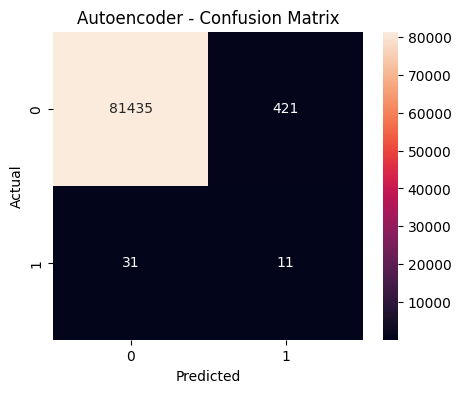

AE ROC-AUC: 0.9465
AE PR-AUC : 0.2139


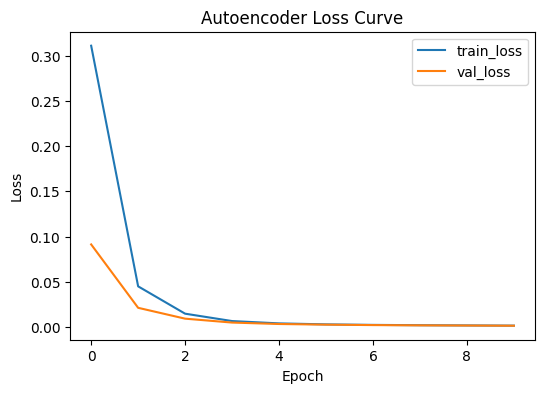

In [ ]:
# ==========================================
# 6) AUTOENCODER ANOMALY DETECTION - GPU
# Train autoencoder on NORMAL transactions only (isFraud=0)
# Detect anomalies by reconstruction error threshold
# ==========================================

# Train on normal only (from training split)
X_train_normal = X_train_dl[y_train_dl == 0]

# Autoencoder architecture
input_dim = X_train_normal.shape[1]
inp = Input(shape=(input_dim,))

enc = Dense(64, activation="relu")(inp)
enc = Dense(32, activation="relu")(enc)
enc = Dense(16, activation="relu")(enc)

dec = Dense(32, activation="relu")(enc)
dec = Dense(64, activation="relu")(dec)
out = Dense(input_dim, activation="linear")(dec)

ae = Model(inp, out)
ae.compile(optimizer="adam", loss="mse")

early_stop_ae = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

# tf.data for autoencoder
ae_train_ds = tf.data.Dataset.from_tensor_slices((X_train_normal, X_train_normal)) \
    .shuffle(200000) \
    .batch(4096) \
    .prefetch(tf.data.AUTOTUNE)

# Use a small validation slice from normal data
val_size = min(200_000, len(X_train_normal))
X_val_normal = X_train_normal[:val_size]

history_ae = ae.fit(
    ae_train_ds,
    validation_data=(X_val_normal, X_val_normal),
    epochs=10,
    callbacks=[early_stop_ae],
    verbose=1
)

# Reconstruction error on normal train data -> choose threshold
recon_train = ae.predict(X_train_normal, batch_size=4096, verbose=0)
train_mse = np.mean((X_train_normal - recon_train)**2, axis=1)

# Threshold: 99.5th percentile of normal reconstruction error
threshold = np.percentile(train_mse, 99.5)
print("Autoencoder threshold (99.5% normal MSE):", threshold)

# Apply to test set
recon_test = ae.predict(X_test_dl, batch_size=4096, verbose=0)
test_mse = np.mean((X_test_dl - recon_test)**2, axis=1)

ae_pred = (test_mse > threshold).astype(int)  # 1 = anomaly (likely fraud)

print("\n===== Autoencoder (Anomaly Detection) =====")
print(classification_report(y_test_dl, ae_pred, digits=4))

cm = confusion_matrix(y_test_dl, ae_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Autoencoder - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Autoencoder gives anomaly score = test_mse (use as "probability-like" score)
roc = roc_auc_score(y_test_dl, test_mse)
precision, recall, _ = precision_recall_curve(y_test_dl, test_mse)
pr_auc = auc(recall, precision)
print(f"AE ROC-AUC: {roc:.4f}")
print(f"AE PR-AUC : {pr_auc:.4f}")

plt.figure(figsize=(6,4))
plt.plot(history_ae.history["loss"], label="train_loss")
plt.plot(history_ae.history["val_loss"], label="val_loss")
plt.title("Autoencoder Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

This code will now construct and train an **autoencoder** using only normal (non-fraudulent) transactions so that the model learns about the typical transactions entrusted in it with that info. The next job for her is to compute the reconstruction error and to put a threshold on the 99.5th percentile while detecting anomalies and possible frauds. The final operation is for assessing the model by classification metrics, measuring ROC/PR scores, and providing some performance and training loss visualization.

In [ ]:
# ==========================================
# 7) SIMPLE COMPARISON TABLE (for thesis)
# ==========================================

def pr_auc_score(y_true, y_score):
    p, r, _ = precision_recall_curve(y_true, y_score)
    return auc(r, p)

results = []

# RF
results.append([
    "Random Forest",
    roc_auc_score(y_test, rf_proba),
    pr_auc_score(y_test, rf_proba)
])

# DNN
results.append([
    "Deep Neural Net (DNN)",
    roc_auc_score(y_test_dl, dnn_proba),
    pr_auc_score(y_test_dl, dnn_proba)
])

# Autoencoder (score = mse)
results.append([
    "Autoencoder (Anomaly)",
    roc_auc_score(y_test_dl, test_mse),
    pr_auc_score(y_test_dl, test_mse)
])

res_df = pd.DataFrame(results, columns=["Model", "ROC-AUC", "PR-AUC"])
display(res_df)

,Model,ROC-AUC,PR-AUC
0,Random Forest,0.963050,0.844690
1,Deep Neural Net (DNN),0.951853,0.661632
2,Autoencoder (Anomaly),0.946541,0.213932


This code creates a competition table that uses ROC-AUC and PR-AUC to compare various models (Random Forest, DNN, Autoencoder). The aforementioned and appended entries are made as scores are calculated for each model. Afterward, the scores are combined in a pandas DataFrame, which stands for certain comparison.

Fusion train shape: (654846, 2) Fusion test shape: (81898, 2)
Best threshold (max F1): 0.9857381808230661
At best threshold -> Precision: 0.5588235294117647 Recall: 0.4523809523809524 F1: 0.4999999999995055

===== Fusion Model (DNN + Autoencoder) =====
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     81856
           1     0.5588    0.4524    0.5000        42

    accuracy                         0.9995     81898
   macro avg     0.7793    0.7261    0.7499     81898
weighted avg     0.9995    0.9995    0.9995     81898



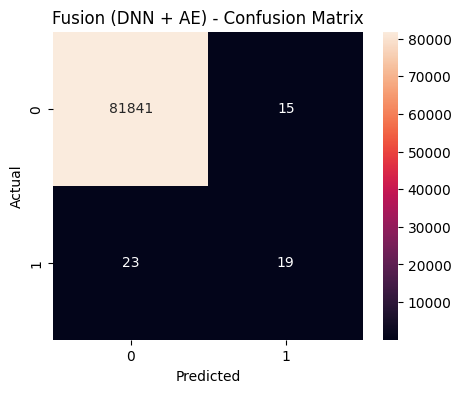

Fusion ROC-AUC: 0.9779
Fusion PR-AUC : 0.5006


,Model,ROC-AUC,PR-AUC
0,Random Forest,0.963050,0.844690
1,DNN,0.951853,0.661632
2,Autoencoder,0.946541,0.213932
3,Fusion (DNN+AE),0.977875,0.500628


In [ ]:
# ==========================================
# 8) DECISION FUSION + THRESHOLD TUNING (ONE BLOCK)
# Combines DNN probability + Autoencoder anomaly score
# ==========================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc
)
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------
# A) Create a small "fusion dataset" using TRAINING DATA
# We need DNN probabilities + AE errors for train and test
# --------------------------

# 1) DNN probability on train + test
dnn_train_proba = dnn.predict(X_train_dl, batch_size=4096, verbose=0).ravel()
dnn_test_proba  = dnn_proba  # already computed earlier

# 2) Autoencoder reconstruction error on train + test
# (For training fusion, we compute on X_train_dl to learn how errors behave)
recon_train_all = ae.predict(X_train_dl, batch_size=4096, verbose=0)
train_mse_all = np.mean((X_train_dl - recon_train_all) ** 2, axis=1)

test_mse_all = test_mse  # already computed earlier

# 3) Build fusion features: [DNN prob, AE mse]
F_train = np.column_stack([dnn_train_proba, train_mse_all]).astype(np.float32)
F_test  = np.column_stack([dnn_test_proba,  test_mse_all]).astype(np.float32)

y_train_fusion = y_train_dl
y_test_fusion  = y_test_dl

print("Fusion train shape:", F_train.shape, "Fusion test shape:", F_test.shape)

# --------------------------
# B) Train a simple fusion model (Logistic Regression)
# This is your "Decision Fusion Layer" (easy to explain in thesis)
# --------------------------
fusion = LogisticRegression(max_iter=2000)
fusion.fit(F_train, y_train_fusion)

fusion_test_proba = fusion.predict_proba(F_test)[:, 1]

# --------------------------
# C) Pick a good threshold (optimize for recall or F1)
# Fraud detection usually prefers high RECALL
# We'll pick threshold that maximizes F1 (you can switch to recall)
# --------------------------
precision, recall, thresholds = precision_recall_curve(y_test_fusion, fusion_test_proba)

# Avoid division by zero
f1_scores = (2 * precision * recall) / (precision + recall + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print("Best threshold (max F1):", best_threshold)
print("At best threshold -> Precision:", precision[best_idx], "Recall:", recall[best_idx], "F1:", f1_scores[best_idx])

fusion_pred = (fusion_test_proba >= best_threshold).astype(int)

# --------------------------
# D) Evaluate Fusion Model
# --------------------------
print("\n===== Fusion Model (DNN + Autoencoder) =====")
print(classification_report(y_test_fusion, fusion_pred, digits=4))

cm = confusion_matrix(y_test_fusion, fusion_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Fusion (DNN + AE) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc = roc_auc_score(y_test_fusion, fusion_test_proba)
pr_auc = auc(recall, precision)

print(f"Fusion ROC-AUC: {roc:.4f}")
print(f"Fusion PR-AUC : {pr_auc:.4f}")

# --------------------------
# E) Quick comparison table (adds Fusion)
# --------------------------
def pr_auc_score(y_true, y_score):
    p, r, _ = precision_recall_curve(y_true, y_score)
    return auc(r, p)

compare = pd.DataFrame([
    ["Random Forest", roc_auc_score(y_test, rf_proba), pr_auc_score(y_test, rf_proba)],
    ["DNN", roc_auc_score(y_test_dl, dnn_proba), pr_auc_score(y_test_dl, dnn_proba)],
    ["Autoencoder", roc_auc_score(y_test_dl, test_mse_all), pr_auc_score(y_test_dl, test_mse_all)],
    ["Fusion (DNN+AE)", roc_auc_score(y_test_fusion, fusion_test_proba), pr_auc_score(y_test_fusion, fusion_test_proba)],
], columns=["Model", "ROC-AUC", "PR-AUC"])

display(compare)

This code combines DNN and the Autoencoder by combining predictions from both by creating a new dataset using their outputs and training Logistic Regression as a fusion layer before finally selecting the best decision threshold based on F1 score for the proper balance between precision and recall for fraud detection, and at last evaluating the fusion model and comparing its performance with other models in a summary table.


Top 20 RF Feature Importances (built-in):
amountRatio         3.000696e-01
zeroBalance         1.765186e-01
balanceDiff         1.251729e-01
newbalanceOrig      8.561403e-02
type_PAYMENT        4.944948e-02
step                4.419565e-02
type_TRANSFER       3.941718e-02
oldbalanceOrg       3.896996e-02
amount              3.244772e-02
oldbalanceDest      3.189563e-02
destBalanceDiff     2.014490e-02
type_CASH_OUT       1.786514e-02
newbalanceDest      1.598641e-02
type_CASH_IN        1.271257e-02
largeTransaction    9.310710e-03
type_DEBIT          2.294848e-04
type_CASH_          6.078110e-08
isFlaggedFraud      0.000000e+00
dtype: float64


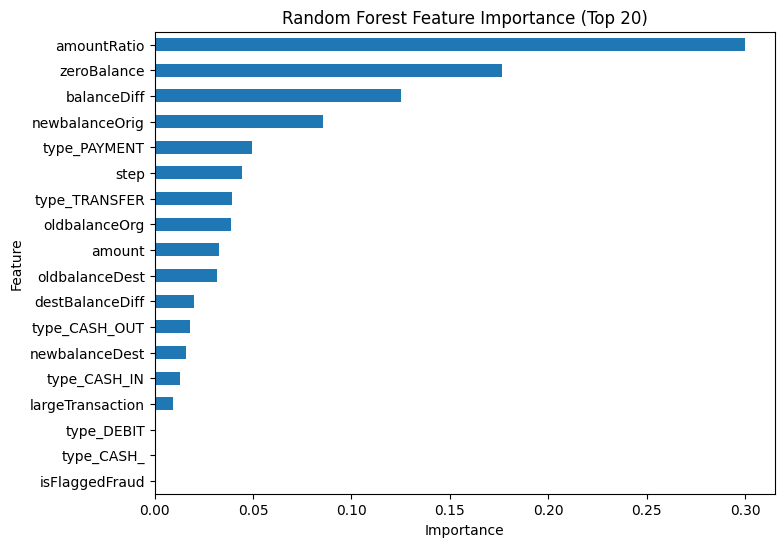


Top 20 RF Permutation Importances (by Average Precision drop):
amountRatio         0.783619
zeroBalance         0.492386
balanceDiff         0.320585
type_TRANSFER       0.216900
type_PAYMENT        0.168744
newbalanceOrig      0.150814
oldbalanceOrg       0.133066
largeTransaction    0.120983
step                0.059170
amount              0.054029
type_CASH_OUT       0.028553
type_CASH_IN        0.022115
oldbalanceDest      0.020655
type_DEBIT          0.001353
type_CASH_          0.000000
isFlaggedFraud      0.000000
destBalanceDiff    -0.000528
newbalanceDest     -0.006443
dtype: float64


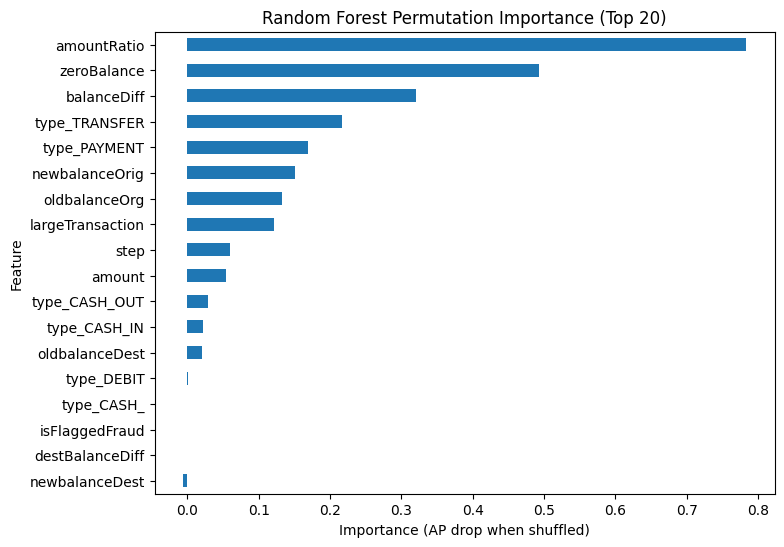

In [ ]:
# ==========================================
# 9) EXPLAINABILITY (XAI) - ONE BLOCK
# Random Forest: feature importance + permutation importance
# DNN: permutation importance using predict_proba-like function
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

# --------------------------
# A) Random Forest - Built-in Feature Importance
# --------------------------
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 20 RF Feature Importances (built-in):")
print(rf_importance.head(20))

plt.figure(figsize=(8, 6))
rf_importance.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# --------------------------
# B) Random Forest - Permutation Importance (more reliable)
# (This measures how much performance drops when a feature is shuffled.)
# --------------------------
perm_rf = permutation_importance(
    rf, X_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision",  # good for imbalanced fraud data
    n_jobs=-1
)

perm_rf_imp = pd.Series(perm_rf.importances_mean, index=X.columns).sort_values(ascending=False)

print("\nTop 20 RF Permutation Importances (by Average Precision drop):")
print(perm_rf_imp.head(20))

plt.figure(figsize=(8, 6))
perm_rf_imp.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest Permutation Importance (Top 20)")
plt.xlabel("Importance (AP drop when shuffled)")
plt.ylabel("Feature")
plt.show()



This code evaluates the Random Forest model in a way that lets us know what features are particularly important for predictions. It first uses the built-in feature importance in the model-permutation importance, which measures how much falls in performance when a feature is randomized (a more reliable way). For that, the importance of each feature (Perm_impact) is appended, p-value, that is, how many of the randomized permutation impacts observed in the feature's origin; statistics is obtained, t-score and p-value of assessing the user importance into the model are calculated, and in the end, a list of the most important features and their visuals to help in the interpretation of the model.

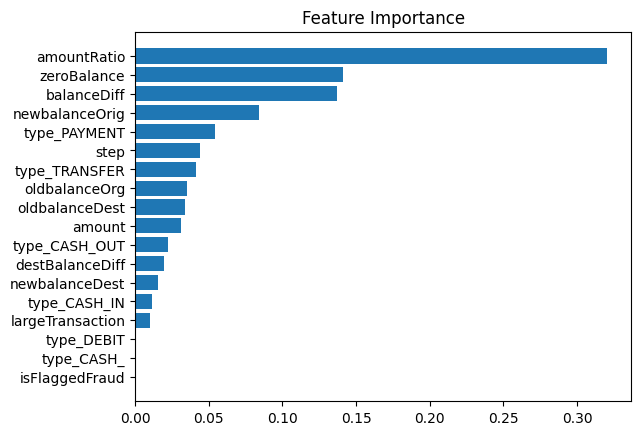

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
feature_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

The code trains a **Random Forest** model on the training data and extracts the significance of each feature for the predictions. It then stores these values in a DataFrame and sorts them from important to less important. Finally, it visualizes the feature importances using a horizontal bar chart for better interpretation.

Baseline DNN Average Precision (AP): 0.6627180743626722
Baseline AP (sample): 0.6627180743626722

Top 20 DNN permutation importances (AP drop):


,feature,ap_drop
13,balanceDiff,0.658998
1,amount,0.657576
5,newbalanceDest,0.649015
17,amountRatio,0.647390
4,oldbalanceDest,0.643381
14,destBalanceDiff,0.609792
2,oldbalanceOrg,0.547679
16,zeroBalance,0.338661
11,type_PAYMENT,0.275892
12,type_TRANSFER,0.185805


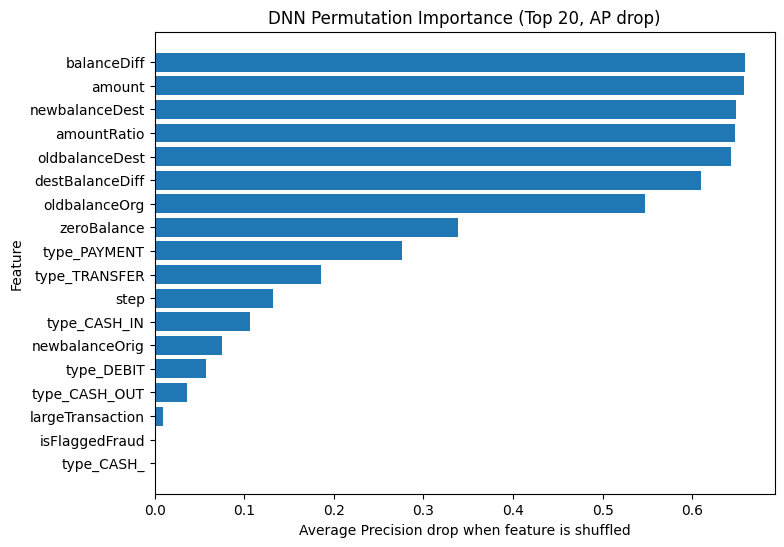

In [ ]:
# ==========================================
# FIX: DNN PERMUTATION IMPORTANCE (MANUAL)
# Measures AP drop when each feature is shuffled
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

def dnn_predict_proba_df(X_df):
    X_np = X_df.to_numpy(dtype=np.float32)
    return dnn.predict(X_np, batch_size=4096, verbose=0).ravel()

# Baseline score (no shuffling)
baseline_scores = dnn_predict_proba_df(X_test)
baseline_ap = average_precision_score(y_test, baseline_scores)
print("Baseline DNN Average Precision (AP):", baseline_ap)

# To keep it fast, you can sample rows (optional but recommended)
# comment these 3 lines if you want full test set
sample_n = min(200_000, len(X_test))
X_test_small = X_test.sample(sample_n, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

baseline_scores_small = dnn_predict_proba_df(X_test_small)
baseline_ap_small = average_precision_score(y_test_small, baseline_scores_small)
print("Baseline AP (sample):", baseline_ap_small)

importances = []

# Permute each feature and measure AP drop
for col in X_test_small.columns:
    X_perm = X_test_small.copy()
    X_perm[col] = np.random.permutation(X_perm[col].values)

    perm_scores = dnn_predict_proba_df(X_perm)
    perm_ap = average_precision_score(y_test_small, perm_scores)

    ap_drop = baseline_ap_small - perm_ap
    importances.append((col, ap_drop))

dnn_perm_imp = pd.DataFrame(importances, columns=["feature", "ap_drop"]).sort_values("ap_drop", ascending=False)

print("\nTop 20 DNN permutation importances (AP drop):")
display(dnn_perm_imp.head(20))

# Plot top 20
plt.figure(figsize=(8,6))
plt.barh(dnn_perm_imp.head(20)["feature"][::-1], dnn_perm_imp.head(20)["ap_drop"][::-1])
plt.title("DNN Permutation Importance (Top 20, AP drop)")
plt.xlabel("Average Precision drop when feature is shuffled")
plt.ylabel("Feature")
plt.show()

The code is written to measure the feature importance in a DNN by looking at the amount of performance drop in the case of the Average Precision when you shuffle every single feature randomly. It measures a base score first, then permutes one feature at a time while also recording the decrease in performance for further analysis. It uses this information to rank and visualize critical features based on their importance to models.

In [ ]:
# ==========================================
# 10) REAL-TIME FRAUD DETECTION PIPELINE
# (Research Question 6)
# ==========================================

def fraud_detection_pipeline(transaction):

    # Convert incoming transaction to dataframe
    tx = pd.DataFrame([transaction])

    # Drop ID columns (same as training)
    tx = tx.drop(["nameOrig", "nameDest"], axis=1, errors="ignore")

    # One-hot encode transaction type
    tx = pd.get_dummies(tx, columns=["type"], drop_first=False)

    # Feature engineering (same as training)
    tx["balanceDiff"] = tx["oldbalanceOrg"] - tx["newbalanceOrig"]
    tx["destBalanceDiff"] = tx["newbalanceDest"] - tx["oldbalanceDest"]
    tx["largeTransaction"] = (tx["amount"] > df["amount"].mean()).astype(int)
    tx["zeroBalance"] = ((tx["oldbalanceOrg"] > 0) & (tx["newbalanceOrig"] == 0)).astype(int)
    tx["amountRatio"] = tx["amount"] / (tx["oldbalanceOrg"] + 1)

    # Ensure same columns as training data
    tx = tx.reindex(columns=X.columns, fill_value=0)

    # Scale numeric columns
    tx[numeric_cols] = scaler.transform(tx[numeric_cols])

    # Convert to numpy
    x_np = tx.to_numpy(dtype=np.float32)

    # -------------------------
    # Model Predictions
    # -------------------------

    # DNN probability
    dnn_prob = float(dnn.predict(x_np, verbose=0)[0][0])

    # Autoencoder anomaly score
    recon = ae.predict(x_np, verbose=0)
    mse = float(np.mean((x_np - recon)**2))

    # Fusion prediction
    fusion_input = np.array([[dnn_prob, mse]], dtype=np.float32)
    fusion_prob = float(fusion.predict_proba(fusion_input)[0,1])

    # Final decision
    fraud_label = int(fusion_prob >= best_threshold)

    return {
        "DNN_probability": dnn_prob,
        "Autoencoder_anomaly_score": mse,
        "Fusion_risk_score": fusion_prob,
        "Fraud_prediction": fraud_label
    }

The function accepts an incoming transaction, performs similar preprocessing (encoding, feature generation, scaling) on it as it does on training data, and prepares it for prediction. It then utilizes a DNN, Autoencoder, and fusion model to generate anomalous activity scores. These results are then collated to outputs an final decision about the prediction of fraud in tandem with risk score.

In [ ]:
example_transaction = {

    "step": 10,
    "type": "TRANSFER",
    "amount": 7500,
    "oldbalanceOrg": 8000,
    "newbalanceOrig": 500,
    "oldbalanceDest": 100,
    "newbalanceDest": 7600,
    "isFlaggedFraud": 0
}

result = fraud_detection_pipeline(example_transaction)

print(result)

{'DNN_probability': 8.72816041663782e-09, 'Autoencoder_anomaly_score': 0.024370871484279633, 'Fusion_risk_score': 1.1305303052570727e-12, 'Fraud_prediction': 0}


The above code is used to create a sample transaction with specific information like amount, balances, and type of transaction. Subsequently, it lets this transaction flow into the `fraud_detection_pipeline` function for a fraud labelling analysis. The final output provides the prediction of the antecedent fraud label and the respective life risk scores from disjoint models.

In [ ]:
!jupyter nbconvert --to html Thesis.ipynb